In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [3]:
regions = pd.read_csv(
    "../../../data/processed/airports/regions/regions_processed.csv"
)

In [4]:
regions.head()

,id,code,local_code,name,continent,iso_country
0,302811,AD-02,02,Canillo Parish,EU,AD
1,302812,AD-03,03,Encamp Parish,EU,AD
2,302813,AD-04,04,La Massana Parish,EU,AD
3,302814,AD-05,05,Ordino Parish,EU,AD
4,302815,AD-06,06,Sant Julià de Lòria Parish,EU,AD


In [5]:
regions.shape

(3982, 6)

In [6]:
regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3982 entries, 0 to 3981
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           3982 non-null   int64 
 1   code         3982 non-null   object
 2   local_code   3978 non-null   object
 3   name         3982 non-null   object
 4   continent    3542 non-null   object
 5   iso_country  3967 non-null   object
dtypes: int64(1), object(5)
memory usage: 186.8+ KB


## Numerical Analysis

The regions dataset does not contain meaningful numerical variables suitable for statistical analysis. The only numerical attribute (`id`) is an internal identifier and is therefore excluded from numerical exploratory analysis.

In [7]:
continent = regions["continent"].value_counts(dropna=False)

continent

continent
EU     1093
AS     1082
AF      905
NaN     440
SA      257
OC      203
AN        2
Name: count, dtype: int64

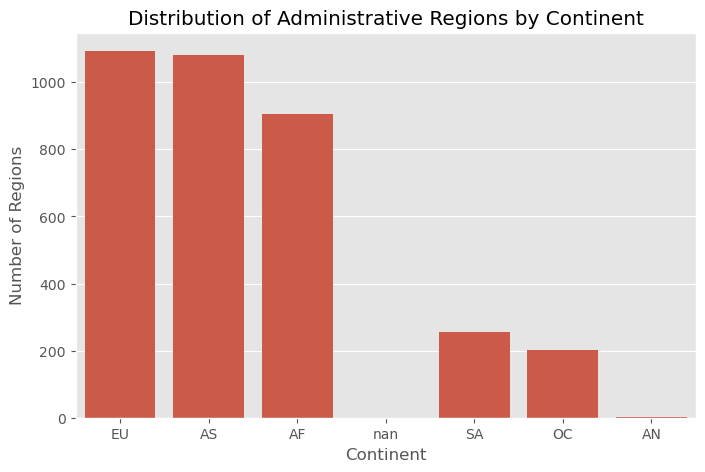

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="continent",
    data=regions,
    order=continent.index
)

plt.title("Distribution of Administrative Regions by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of Regions")

plt.show()

In [9]:
top_countries = (
    regions["iso_country"]
    .value_counts()
    .head(20)
)

top_countries

iso_country
SI    197
PH     90
RU     85
TR     82
TH     78
AZ     74
MT     69
BF     59
DZ     59
US     52
JP     48
KE     48
LV     44
HU     43
RO     43
ID     39
MD     38
NG     38
IN     37
AF     35
Name: count, dtype: int64

In [10]:
regions.isnull().sum()

id               0
code             0
local_code       4
name             0
continent      440
iso_country     15
dtype: int64

In [11]:
missing = pd.DataFrame({
    "Missing Values": regions.isnull().sum(),
    "Percentage": (
        regions.isnull().mean()*100
    ).round(2)
})

missing

,Missing Values,Percentage
id,0,0.00
code,0,0.00
local_code,4,0.10
name,0,0.00
continent,440,11.05
iso_country,15,0.38


In [12]:
regions["region_name_length"] = (
    regions["name"].str.len()
)

regions.nlargest(
    10,
    "region_name_length"
)[["name","region_name_length"]]

,name,region_name_length
1725,Jeonbuk Teukbyeoljachi-do (North Jeolla Specia...,72
1722,Gangwon Teukbyeoljachi-do (Gangwon Special Sel...,67
1729,Jeju Teukbyeoljachi-do (Jeju Special Self-Gove...,61
1031,"Southern Nations, Nationalities, and Peoples' ...",52
733,"San Andrés, Providencia y Santa Catalina Depar...",51
1986,Stînga Nistrului (administrative territorial u...,51
1717,Incheon-Gwangyeoksi (Incheon Metropolitan City),47
1718,Gwangju-gwangyeoksi (Gwangju Metropolitan City),47
1719,Daejeon-gwangyeoksi (Daejeon Metropolitan City),47
1723,Chungcheongbuk-do (North Chungcheong Province),46


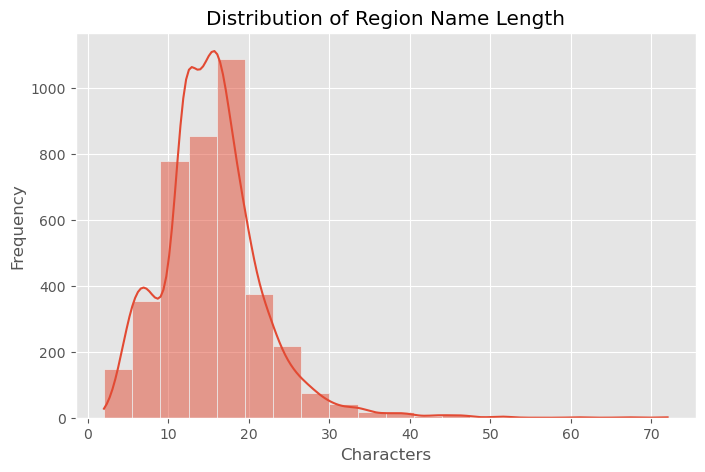

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    regions["region_name_length"],
    bins=20,
    kde=True
)

plt.title("Distribution of Region Name Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [14]:
regions["code"].str.len().describe()

count    3982.000000
mean        5.214967
std         0.568800
min         4.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         7.000000
Name: code, dtype: float64

In [15]:
regions["local_code"].str.len().describe()

count    3978.000000
mean        2.214932
std         0.569361
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: local_code, dtype: float64

In [16]:
continent_regions = (
    regions.groupby("continent")
    .size()
    .sort_values(ascending=False)
)

continent_regions

continent
EU    1093
AS    1082
AF     905
SA     257
OC     203
AN       2
dtype: int64

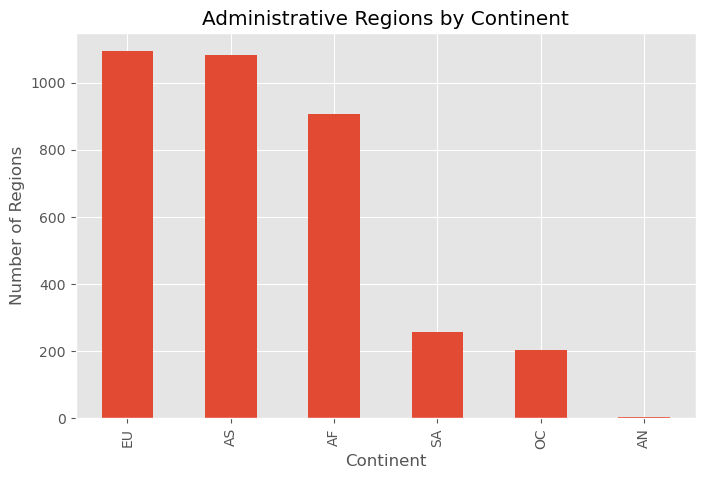

In [17]:
plt.figure(figsize=(8,5))

continent_regions.plot(
    kind="bar"
)

plt.title("Administrative Regions by Continent")

plt.xlabel("Continent")

plt.ylabel("Number of Regions")

plt.show()

## Exploratory Data Analysis Summary

The exploratory analysis confirms that the regions dataset provides comprehensive administrative region coverage across the world. Countries vary considerably in the number of administrative regions they contain, reflecting differences in political and administrative organization. Missing values are limited and correspond to incomplete information in the original reference dataset. Since this dataset serves as a geographic lookup table, the analysis focuses on validating completeness, consistency, and regional coverage rather than numerical relationships. The dataset is suitable for enriching airport records during the Airport Module integration stage.